# $\Gamma$.1: Histogram Reminder <a id="hrem" />

If you have already done the C [Event Sample Selection](./3EventSamples.ipynb) notebook, you can skip to the next section [Spot The Difference Between These Two Histograms](#sec2).

Histograms are ubiquitous in HEP analysis. Each observed particle interaction contains many inherently random properties and it is only after observing many such interactions that we can build up a detailed-enough understanding to spot and model patterns in the data that we think are governed by fundamental physical laws.

As an example, we will use the `numpy` library to sample 100 times from the normal distribution and histogram the results of that sampling. Each sample consists of a value of $x$ which is then _binned_ in the histogram such that the number of times we sampled $x$ and it fell within the range of some bin is recorded.

We will also introduce two helper functions which give us control over how the histogram is defined and filled, and then visualised. The code for these tools can be found in the [proj_utils](./proj_utils/__init__.py) module, but the hope is that you shouldn't need to see the details once you know how to use them. Behind the scenes the ubiquitous python libraries [numpy](), [matplotlib](), and [scipy]() are used. You don't need to know anything about these tools already, but you should be able to find help for any problems encountered via search engine results.

We define a uniform binning with `nbins` spanning `start` to `stop` in $x$ and then visualise the histogram of the samples. As the sampling process is random, try re-running the cell a few times to see the histogram change.

We also overlay the Gaussian function that defines the normal distribution. Try changing the number of samples and re-running the cell a few times. What does this tell us about making measurements with histograms containing many samples? Or histograms containing few samples?

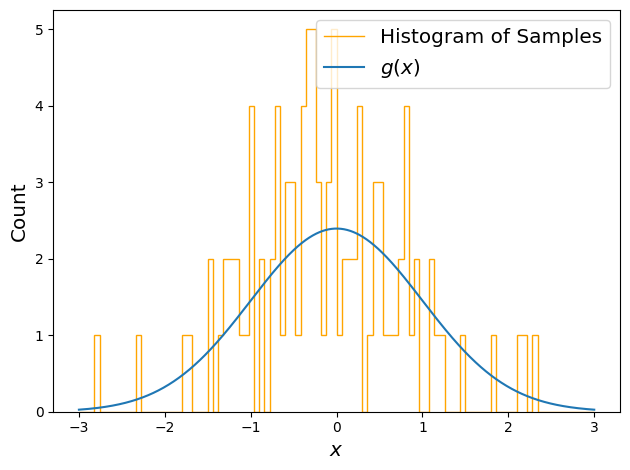

In [1]:
import numpy as np
from proj_utils import hist1d, drawhist1d, drawgaus
import matplotlib.pyplot as plt

rng = np.random.default_rng()
num_samples = 100 # change me
samples = rng.normal(loc=0, scale=1, size=num_samples)

start = -3
stop = 3
nbins = 100
num = nbins + 1

bins = np.linspace(start=start, stop=stop, num=num)
one_draw_hist = hist1d(data=samples, bins=bins)
drawhist1d(hist=one_draw_hist, color="orange", label="Histogram of Samples")

drawgaus(num_samples, loc=0, scale=1, bins=bins)

plt.xlabel(r"$x$", size="x-large")
plt.ylabel(r"Count", size="x-large")

plt.legend(fontsize="x-large")
plt.tight_layout()
plt.show()

If you have any questions about histograms, please ask!

# $\Gamma$.2: Spot The Difference Between These Two Histograms <a id="sec2" />

How _similar_ are these two histograms?

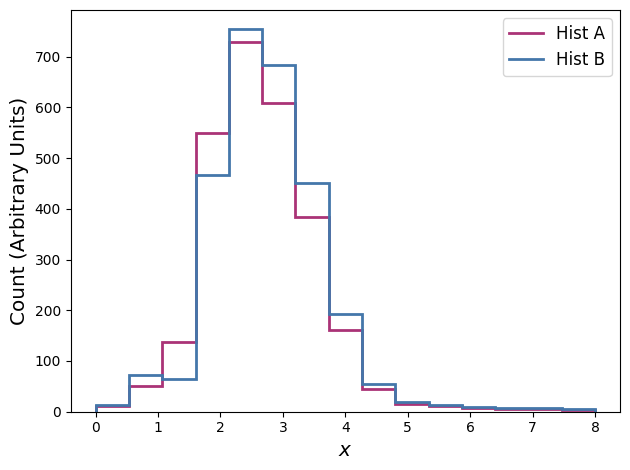

In [2]:
from proj_utils import draw_comp_h1
draw_comp_h1()

How about these?

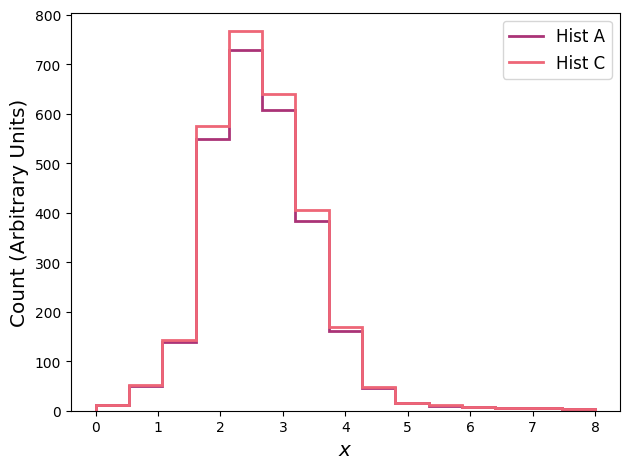

In [3]:
from proj_utils import draw_comp_h2
draw_comp_h2()

What if we draw _error bars_ on one of the histograms? The error bars represent an estimate in the uncertainty on the number of counts in a given bin.

Now would you say Hist B or Hist C is more _compatible_ with Hist A? Why? How might you quantify it?

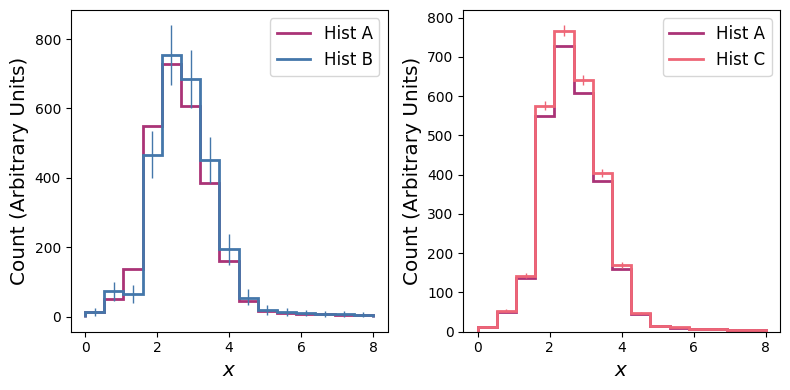

In [4]:
from proj_utils import draw_comp_h3
draw_comp_h3()

# $\Gamma$.3: The Likelihood

The _likelihood_ of some observation given a statistical model is an important concept that appears everywhere in statistical modelling. We will gloss over much of the rigorous mathematical derivation, but some details of the key concepts are important to discuss.

The likelihood, $\mathcal{L}$, is the probability that some _observation_ can be explained as a random sampling of some model, $M(\theta)$. This relates to the [Histogram Reminder](#hrem) exercise at the top of this notebook. We _know_ that the random $x$ samples were distributed according to our chosen gaussian distribution, but what if instead of generating the samples from a mathematical model ourself, the samples came from measurements of some process in the real world and we are trying to build a statistical model to explain that process and make future predictions about the process? If we flip the problem around and say: _We have made this measurement of $x$. How compatible is that measurement with being distributed like a Gaussian? A Gaussian with what *location* and *scale* parameters?_ This approach at the very core of making measurements in HEP (and more widely in science), the physical and statistical models may need to be significantly more complicated than simple Gaussians, but the statistical approach we will develop is general. Don't worry if it isn't clear yet, we will walk through a few examples and hopefully build up your statistical intuition.

We will stick with the Gaussian model, as it turns out that it is a good model for comparing histograms filled with many samples (its less good if you are studying an ultra rare process), but we will use it in a slightly different way. Remember that our current aim is to develop the ability to calculate how _compatible_ (or similar) two histograms are. In the first exercise the quantity that was distributed according to a Gaussian was $x$, if we want to use a Gaussian model to compare histograms, the quantity that we are modelling as being distributed is the height of each bin; or what might traditionally be called the y axis. It might be worth reading that sentence again a few times and asking about it if it isn't clear. 

Previously we had samples that were distributed according to a Gaussian and we used a histogram to summarise the samples and compared the whole histogram to a Gaussian. But now, we are saying that we should treat each bin in our histogram independently and ask whether the observed height of that bin is compatible with a random gaussian distribution about the physical model we are testing.

Below we have an example where the physical process we are measuring is not distributed like a Gaussian in the hope that the distinction between the physical process and the statical model describing each bin can become more clear.

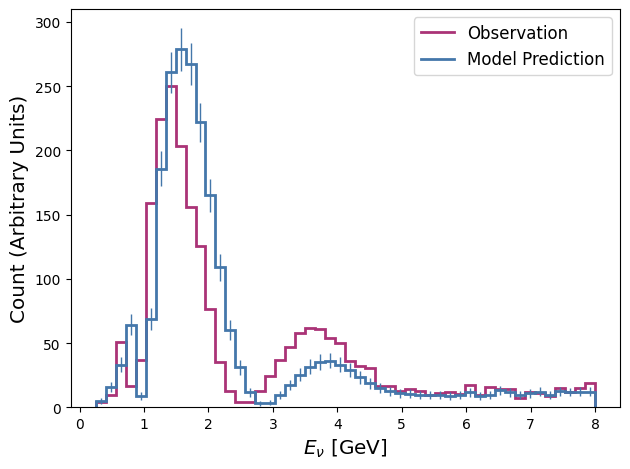

In [1]:
from proj_utils import draw_comp_h4
draw_comp_h4()

Here, the physical process we are observing is one that you have seen recently. The histograms above contain counts of observations and an experimental simulation (model) prediction of the energy distribution of surviving muon neutrinos after oscillation has occured. The error bars around each bin of the model prediction histogram show the expected range of random observations if the model is a correct prediction of nature. Do you think that this model a good predictor of the observation? Why or why not?

To build a mathematical expression for how _likely_ it is that the _observation_ is a random sampling of the _model_ we need to remember two things:
1. The probability for two independent processes to occur is simply the multiplcation of the probability for each process to occur
2. The mathematical form of the Gaussian Probability Density Function: $$g(x, \mu, \sigma) = \frac{1}{\sigma\sqrt{2\pi}}\exp{\left[-\frac{(x-\mu)^2}{2\sigma^2}\right]},$$ where $\mu$ controls the center of the distribution (sometimes called the location), and $\sigma$ controls the width (sometimes called the scale).

We will treat each bin independently as we do not expect a random fluctuation in one bin to affect the value in any other bin. We will then use a Gaussian for each bin, $i$, to calculate the probability of observing a count of $d_i$ given a predicted rate of $\mu_i$ with a width, or uncertainty of $\sigma_i$. For a random process, the standard uncertainty is simply $\sqrt{\mu_i}$. The derivation of the standard uncertainty is not important for our understanding, but if you are interested, it comes from the variance of a [Poisson](https://en.wikipedia.org/wiki/Poisson_distribution) process being equal to the mean parameter, $\lambda$, which is equivalent in our case to our predicted rate parameter, $\mu_i$. The standard deviation, or uncertainty, is then the square root of the variance, $\sigma = \sqrt{\mathrm{Var}} = \sqrt{\mu_i}$.

This has been a lot of reading, but we are nearly there. Putting all this together we can write down the likelihood for $N$ independent bins as $$\mathcal{L} = g(x_1, \mu_1, \sqrt(\mu_1)) \times g(x_1, \mu_1, \sqrt(\mu_1)) \times \dots \times g(x_N, \mu_N, \sqrt(\mu_N))$$


## $\Gamma$.3.1: My First Likelihood Scan


# $\Gamma$.4: Measuring a Parameter


# $\Gamma$.5: Automating the Process
